<a href="https://colab.research.google.com/github/pedrojrcruz30-code/PROJETO_FINAL_CONTINUADA/blob/main/projeto_final_continuada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJETO FINAL**
## **Inteligência de Carteira NeoCard**

**Entrega:** Notebook (`.ipynb`) + dataset utilizado

---

### **1. O Cliente: NeoCard**

A **NeoCard** é a divisão de cartões de crédito de um banco de varejo de porte médio. A carteira ativa reúne clientes dos segmentos *Classic, Gold, Platinum e Black*, distribuídos pelas cinco regiões do país.

Nos últimos meses, a *Diretoria de Inteligência de Cliente* identificou que decisões importantes — de precificação, de alocação de limite e de priorização de campanhas — vêm sendo tomadas com base em impressões e relatos pontuais das agências, sem um diagnóstico estruturado da base.

> **Cenário:** Você e sua equipe foram contratados como uma consultoria externa para entregar o primeiro diagnóstico analítico completo da carteira de clientes e do comportamento de consumo via cartão.

---

### **O Briefing**

* **De:** Diretoria de Inteligência de Cliente — NeoCard  
* **Para:** Equipe de Consultoria de Dados  
* **Assunto:** Diagnóstico da carteira de cartões — primeira entrega  

> *"Precisamos entender quem são nossos clientes, como o consumo se comporta entre segmentos e regiões, e quais sinais a base esconde sob a sujeira que sempre existe em dado real de produção.*
>
> *Quero um material que eu possa levar para a mesa de diretoria: direto, visual, e com conclusões que eu consiga usar para decidir. Vocês têm liberdade para explorar, mas eu preciso de respostas."*

---


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import openpyxl

df_NeoCard = pd.read_excel("neocard_dataset.xlsx")

display(df_NeoCard)

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação,Cartão Múltiplo NeoCard
1,3492,31,Norte,Classic,NaN,15597.73,100,Indicação,Cartão Múltiplo NeoCard
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência,Cartão Múltiplo NeoCard
3,3926,38,Sul,Gold,NaN,16385.55,201,App,Cartão Múltiplo NeoCard
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo,Cartão Múltiplo NeoCard
...,...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação,Cartão Múltiplo NeoCard
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App,Cartão Múltiplo NeoCard
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App,Cartão Múltiplo NeoCard
3998,3508,43,Centro-Oeste,Platinum,NaN,18291.19,71,App,Cartão Múltiplo NeoCard


## Solicitamos informações/resumo inicias do meu dataset

In [4]:
df_NeoCard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB


### 1. Volume e Tamanho dos Dados

Total de Registros: O DataFrame possui 4.000 entradas (indexadas de 0 a 3.999).

Total de Colunas: Há 9 colunas no total.

### 2. Presença de Valores Ausentes (Dados Faltantes)

A grande maioria das colunas está completa: Colunas como id_cliente, idade, regiao, limite_credito, entre outras, possuem 4.000 valores não-nulos, o que significa que não há dados faltantes nelas.

Alerta de Dados Faltantes: A coluna score_credito possui apenas 3.820 valores não-nulos. Isso significa que existem 180 linhas com valores ausentes (nulos) nessa variável. Será necessário tratar esses dados (por exemplo, preenchendo com a média/mediana ou excluindo essas linhas)

## Descobrindo quantas linhas brancas temos em cada coluna

In [5]:
df_NeoCard.isnull().sum()

,0
id_cliente,0
idade,0
regiao,0
segmento_cartao,0
score_credito,180
limite_credito,0
tempo_relacionamento_meses,0
canal_aquisicao,0
produto_core,0


## Obtendo um resumo estatístico rápido das suas colunas numéricas (por padrão) ou categóricas.

In [6]:
df_NeoCard.describe()

,id_cliente,idade,score_credito,limite_credito,tempo_relacionamento_meses
count,4000.000000,4000.00000,3820.000000,4000.000000,4000.000000
mean,2000.500000,41.22350,640.286911,16896.565375,121.799500
std,1154.844867,14.28678,79.827894,15518.950412,69.750513
min,1.000000,-5.00000,425.000000,8124.240000,1.000000
25%,1000.750000,33.00000,579.000000,14357.762500,60.000000
50%,2000.500000,41.00000,632.000000,15913.115000,122.000000
75%,3000.250000,49.00000,695.000000,17777.115000,185.000000
max,4000.000000,200.00000,897.000000,395222.440000,239.000000


## 1. ⚠️ Inconsistências Críticas (Precisam de Tratamento)

idade (Problemas graves de qualidade de dados):

Mínimo de -5.0: Não existe idade negativa. Isso indica um erro de preenchimento ou ruído no sistema.

Máximo de 200.0: Uma idade de 200 anos é biologicamente impossível, o que confirma a presença de outliers (valores discrepantes) que precisam ser removidos ou corrigidos.

### obs: optamos por achar/contar a quantidade de idades negativas e idades acima de 100 anos.

In [7]:
# Contar quantas idades são negativas
qtd_negativas = (df_NeoCard['idade'] < 0).sum()

# Contar quantas idades são acima de 100 anos
qtd_acima = (df_NeoCard['idade'] > 100).sum()

print(f"Quantidade de idades negativas: {qtd_negativas}")
print(f"Quantidade de idades acima de 100 anos: {qtd_acima}")
print(f"Total de registros com erro na idade: {qtd_negativas + qtd_acima}")

Quantidade de idades negativas: 7
Quantidade de idades acima de 100 anos: 13
Total de registros com erro na idade: 20


# Visualizar idades negativas

obs: decidi observar os dados com idades negativas já que eram poucos, para ver se consigo tirar alguma conclusâo ou achar um padrão e assim realizar determinado tratamento.

ex: canal_aquisição

In [8]:

display(df_NeoCard[df_NeoCard['idade'] < 0])


,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
848,3729,-5,Sudeste,Gold,639.0,17940.27,76,App,Cartão Múltiplo NeoCard
951,3130,-5,Sudeste,Black,771.0,19757.40,102,App,Cartão Múltiplo NeoCard
1392,3829,-5,Nordeste,Black,764.0,20458.66,99,Agência,Cartão Múltiplo NeoCard
1471,3028,-5,Sudeste,Platinum,667.0,16957.20,187,Agência,Cartão Múltiplo NeoCard
3186,3952,-5,Sudeste,Black,831.0,22711.71,159,App,Cartão Múltiplo NeoCard
3204,39,-5,Sudeste,Classic,623.0,18825.27,156,Parceria Varejo,Cartão Múltiplo NeoCard
3214,1828,-5,Sudeste,Gold,609.0,15573.60,189,Agência,Cartão Múltiplo NeoCard


# Visualizar idades acima de 100 anos

In [9]:

display(df_NeoCard[df_NeoCard['idade'] > 100])

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
1071,3101,150,Sudeste,Black,859.0,20316.51,213,Parceria Varejo,Cartão Múltiplo NeoCard
1390,2006,150,Sudeste,Platinum,707.0,18462.78,113,App,Cartão Múltiplo NeoCard
1554,2616,150,Sul,Gold,681.0,16113.30,158,Agência,Cartão Múltiplo NeoCard
2249,994,200,Sudeste,Classic,716.0,18105.39,122,App,Cartão Múltiplo NeoCard
2321,2388,150,Sul,Classic,582.0,14387.74,62,Agência,Cartão Múltiplo NeoCard
2652,1880,150,Sudeste,Gold,652.0,17412.90,8,Agência,Cartão Múltiplo NeoCard
2849,1465,200,Sul,Gold,662.0,15522.70,37,App,Cartão Múltiplo NeoCard
2918,2076,150,Sudeste,Gold,676.0,15227.81,145,App,Cartão Múltiplo NeoCard
3207,91,200,Sul,Classic,557.0,13644.54,85,App,Cartão Múltiplo NeoCard
3423,1665,150,Sudeste,Platinum,726.0,15594.80,60,Parceria Varejo,Cartão Múltiplo NeoCard


## 2. Imputação pela Mediana

Se por algum motivo de negócio você absolutamente não puder perder nenhuma linha (por exemplo, se esses clientes tiverem um histórico financeiro crucial nas outras colunas), o ideal é substituir os valores discrepantes pela mediana da idade.

Por que a mediana e não a média? Olhando o seu describe(), a idade máxima é 200, o que puxa a média para cima. A mediana (o valor de 50%, que é 41 anos) é mais segura contra outliers.

In [10]:
# Cria uma cópia para não afetar o original
df_NeoCard_tratado = df_NeoCard.copy()

# descobrindo a mediana
mediana_idade = df_NeoCard_tratado['idade'].median()

print('A mediana de idade é:', mediana_idade)


A mediana de idade é: 41.0


## Inserindo e Visualizando as alterações atraves do describe

In [11]:
# Aplica a alteração na cópia
df_NeoCard_tratado.loc[(df_NeoCard_tratado['idade'] <= 0) | (df_NeoCard_tratado['idade'] > 100), 'idade'] = mediana_idade

# Agora sim esse comando vai funcionar perfeitamente:
df_NeoCard_tratado.describe().round(2)


,id_cliente,idade,score_credito,limite_credito,tempo_relacionamento_meses
count,4000.00,4000.00,3820.00,4000.00,4000.00
mean,2000.50,40.93,640.29,16896.57,121.80
std,1154.84,11.82,79.83,15518.95,69.75
min,1.00,18.00,425.00,8124.24,1.00
25%,1000.75,33.00,579.00,14357.76,60.00
50%,2000.50,41.00,632.00,15913.12,122.00
75%,3000.25,49.00,695.00,17777.12,185.00
max,4000.00,85.00,897.00,395222.44,239.00


obs: como podemos ver os valores de min e max da coluna Idade já não estão -5.00 e 200, respectivamente.


# Agora trataremos a coluna que contem dados em branco.

In [12]:
df_NeoCard_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB


## - Analisando o resumo do DataFrame, já com alguns tratamentos, ainda consta um item a ser tratado se possivel: os valores ausentes (dados em branco), coluna (score_credito), que tem 3.820 valores preenchidos de um total de 4.000 linhas (ou seja, 180 valores nulos, cerca de 4,5% dos dados).

##  - Aqui optamos por tirar a mediana Geral (score_credito) para preenher os dados faltantes (180 valores nulos). obs: é mais Simples e rápido e não sofre distorção caso existam clientes com scores muito baixos ou muito altos (outliers) no dataset.

In [13]:
mediana_score = df_NeoCard_tratado['score_credito'].median()

print('Mediana do score_credito Geral:', mediana_score)

print('='* 70)

df_NeoCard_tratado['score_credito'] = df_NeoCard_tratado['score_credito'].fillna(mediana_score)

df_NeoCard_tratado.info()

Mediana do score_credito Geral: 632.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               4000 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB



## Não optei pela Remoção das Linhas (A mais radical)

A remoção das linhas não foi adotada para evitar o desperdício de dados. Excluir essas 180 contas significaria perder todo o histórico de limite de crédito e tempo de relacionamento desses clientes, informações valiosas que preferi preservar por meio da imputação.


# Visualizando o DataFrame já com alguns tratamentos.

In [14]:
df_NeoCard_tratado

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação,Cartão Múltiplo NeoCard
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação,Cartão Múltiplo NeoCard
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência,Cartão Múltiplo NeoCard
3,3926,38,Sul,Gold,632.0,16385.55,201,App,Cartão Múltiplo NeoCard
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo,Cartão Múltiplo NeoCard
...,...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação,Cartão Múltiplo NeoCard
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App,Cartão Múltiplo NeoCard
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App,Cartão Múltiplo NeoCard
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App,Cartão Múltiplo NeoCard


# Conseguimos uma informação valiosíssima sobre os dados: todas as 4.000 linhas da sua base possuem exatamente o mesmo produto, que é o 'Cartão Múltiplo NeoCard'. Não há nenhuma variação nessa coluna.

In [16]:
df_NeoCard_tratado['produto_core'].unique()


array(['Cartão Múltiplo NeoCard'], dtype=object)

In [17]:
df_NeoCard_tratado['produto_core'].value_counts()

,count
produto_core,
Cartão Múltiplo NeoCard,4000


# Optamos pela sua exclusão (coluna: "produto_core")

In [18]:
df_NeoCard_tratado.drop(columns=['produto_core'], inplace=False)



,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência
3,3926,38,Sul,Gold,632.0,16385.55,201,App
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo
...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App


In [19]:
df_NeoCard_tratado

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação,Cartão Múltiplo NeoCard
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação,Cartão Múltiplo NeoCard
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência,Cartão Múltiplo NeoCard
3,3926,38,Sul,Gold,632.0,16385.55,201,App,Cartão Múltiplo NeoCard
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo,Cartão Múltiplo NeoCard
...,...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação,Cartão Múltiplo NeoCard
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App,Cartão Múltiplo NeoCard
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App,Cartão Múltiplo NeoCard
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App,Cartão Múltiplo NeoCard


## Fiz uma copia do df_NeoCard_tratado para não perder os dados tratados anteriomente e agora passa a se chamar df_NeoCard_definitivo.

In [20]:
df_NeoCard_definitivo = df_NeoCard_tratado.copy()

df_NeoCard_definitivo.drop(columns=['produto_core'], inplace=True)

df_NeoCard_definitivo

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência
3,3926,38,Sul,Gold,632.0,16385.55,201,App
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo
...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App


## Fiz uma consulta para ver se tinha algum dados(linhas) duplicado no Dataframe.

In [21]:
# Retorna o número total de linhas duplicadas
df_NeoCard_definitivo.duplicated().sum()

np.int64(0)

# Dataframe ponto para analise.

In [22]:
df_NeoCard_definitivo

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência
3,3926,38,Sul,Gold,632.0,16385.55,201,App
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo
...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App


In [23]:
df_NeoCard_definitivo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               4000 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
dtypes: float64(2), int64(3), object(3)
memory usage: 250.1+ KB


# 1. quantidade de cartões por segmento_cartão

In [24]:
# Agrupa por segmento, conta e já renomeia a Series
contagem_segmento = df_NeoCard_definitivo.groupby('segmento_cartao')['id_cliente'].count().rename('quantidade')

# Exibe o resultado
display(contagem_segmento)


,quantidade
segmento_cartao,
Black,290
Classic,1816
Gold,1170
Platinum,724


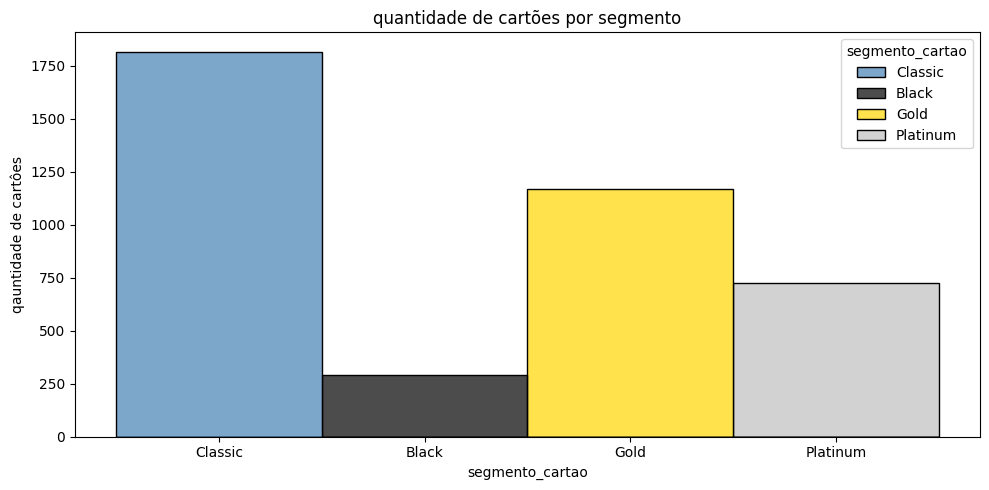

In [31]:
fig, ax = plt.subplots(figsize=(10,5)) # cria subáreas para poder trabalhar com gráficos independentes

cores_customizadas = {
    "Classic": "#4682B4",     # Um azul bonito (SteelBlue) para manter o padrão
    "Black": "black",         # Preto
    "Gold": "#FFD700",        # Dourado clássico
    "Platinum": "silver"      # Cinza/Prata (ou 'gray' se preferir mais escuro)
}

sns.histplot(
    data=df_NeoCard_definitivo, # os dados/dataframe
    x="segmento_cartao", # coluna que vai ser usada no eixo X
    #y="quantidade", # coluna que vai ser usada no eixo X
    hue="segmento_cartao", # semelhante ao group by, agrupando os dados por categoria
    palette=cores_customizadas, # define a paleta de cores personalizada
    bins=40, # quantidade de agrupamentos
    #kde=True, # linha com o a densidade de probabilidade
    alpha=0.7, # transparencia para sobreposição legível
    ax=ax # subarea usada
)

ax.set_title("quantidade de cartões por segmento") # define o título do gráfico
ax.set_xlabel("segmento_cartao") # define a legenda do eixo x
ax.set_ylabel("qauntidade de cartôes") # define a legenda do eixo y

plt.tight_layout() # ajuste de visual
plt.show() # plota os gráficos

# 2. Para ver a média de limite e score de crédito por segmento:

In [26]:
df_NeoCard_definitivo.groupby('segmento_cartao')[['limite_credito', 'score_credito']].mean().round(2)

,limite_credito,score_credito
segmento_cartao,,
Black,19612.63,778.51
Classic,15245.10,581.22
Gold,17144.62,650.21
Platinum,19550.13,715.00


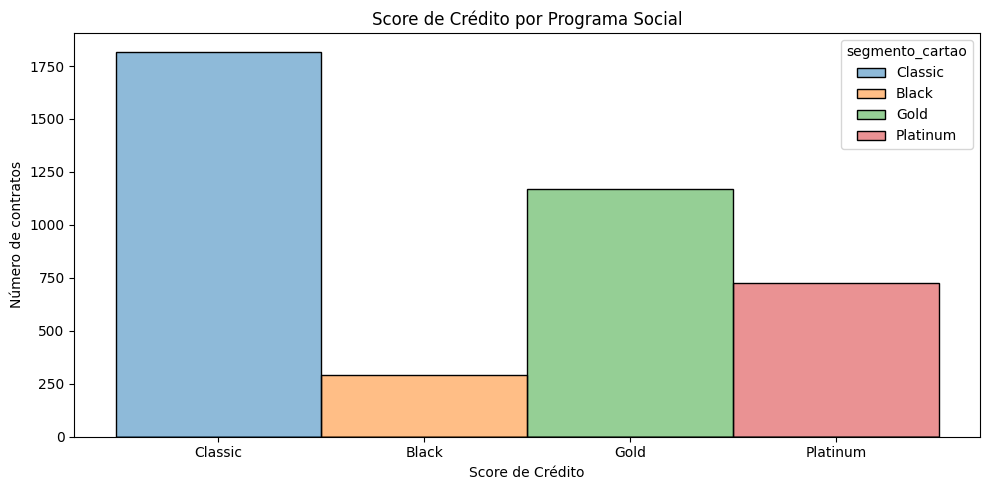

In [27]:
fig, ax = plt.subplots(figsize=(10,5)) # cria subáreas para poder trabalhar com gráficos independentes

sns.histplot(
    data=df_NeoCard_definitivo, # os dados/dataframe
    x="segmento_cartao", # coluna que vai ser usada no eixo X
    hue="segmento_cartao", # semelhante ao group by, agrupando os dados por categoria
    bins=40, # quantidade de agrupamentos
    kde=True, # linha com o a densidade de probabilidade
    alpha=0.5, # transparencia para sobreposição legível
    ax=ax # subarea usada
)

ax.set_title("Score de Crédito por Programa Social") # define o título do gráfico
ax.set_xlabel("Score de Crédito") # define a legenda do eixo x
ax.set_ylabel("Número de contratos") # define a legenda do eixo y

plt.tight_layout() # ajuste de visual
plt.show() # plota os gráficos

# 3. Para contar quantos clientes têm cada tipo de cartão e em termos percentuais.

In [92]:
# Cria um DataFrame com a contagem e o percentual
analise_segmento = df_NeoCard_definitivo.groupby('segmento_cartao')['id_cliente'].agg(
    Quantidade='count',
    Percentual=lambda x: (x.count() / len(df_NeoCard_definitivo)) * 100
)

# Opcional: formata a coluna de percentual para exibir o símbolo % e duas casas decimais
analise_segmento['Percentual'] = analise_segmento['Percentual'].map('{:.2f}%'.format)

analise_segmento

,Quantidade,Percentual
segmento_cartao,,
Black,290,7.25%
Classic,1816,45.40%
Gold,1170,29.25%
Platinum,724,18.10%


# 1. Estatística Descritiva Geral (Idade, Score e Limite)

In [29]:
resumo_geral = df_NeoCard_definitivo[['idade', 'score_credito', 'limite_credito']].describe().round(2)
display(resumo_geral)

,idade,score_credito,limite_credito
count,4000.00,4000.00,4000.00
mean,40.93,639.91,16896.57
std,11.82,78.03,15518.95
min,18.00,425.00,8124.24
25%,33.00,582.00,14357.76
50%,41.00,632.00,15913.12
75%,49.00,691.00,17777.12
max,85.00,897.00,395222.44


O que observar no resultado:

1.   Média (mean) vs Mediana (50%): Se a média de limite_credito for muito maior que a mediana, significa que você tem alguns clientes com limites absurdamente altos puxando a média para cima.

2.   Mínimos e Máximos (min/max): Para entender a amplitude do seu público (ex: se atendem desde jovens de 18 anos até idosos, ou scores muito baixos).



# 2. O perfil muda por segmento de cartão?

### Agrupei por segmento e calculei a média das variáveis numéricas relevantes

In [30]:
perfil_por_segmento = df_NeoCard_definitivo.groupby('segmento_cartao')[['idade', 'score_credito', 'limite_credito']].mean().round(2)
display(perfil_por_segmento)

,idade,score_credito,limite_credito
segmento_cartao,,,
Black,41.07,778.51,19612.63
Classic,41.03,581.22,15245.10
Gold,40.62,650.21,17144.62
Platinum,41.09,715.00,19550.13


💡 Dica de ouro: Como a média pode ser afetada por valores extremos (outliers), vale muito a pena rodar também com a mediana para ver se o padrão se mantém estável:

In [31]:
perfil_por_segmento_mediana = df_NeoCard_definitivo.groupby('segmento_cartao')[['idade', 'score_credito', 'limite_credito']].median().round(2)
display(perfil_por_segmento_mediana)

,idade,score_credito,limite_credito
segmento_cartao,,,
Black,41.0,779.5,19648.46
Classic,41.0,580.0,14617.50
Gold,40.0,648.0,16313.48
Platinum,41.0,715.0,18120.60


Ao olhar a tabela gerada pelo código acima, repare em padrões comuns de mercado. Geralmente, espera-se que:

Score de Crédito: Cartões como Black e Platinum apresentem uma média de score significativamente maior que o Classic.

Limite de Crédito: O limite deve crescer progressivamente conforme a categoria do cartão sobe (Classic < Gold < Platinum < Black).

Idade: é bem distribuída entre os segmentos.

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Lendo a aba específica e ajustando os decimais
df_transacoes = pd.read_excel("neocard_dataset.xlsx", sheet_name="transacoes")

display(df_transacoes)

,id_transacao,id_cliente,data_transacao,categoria,valor_transacao,canal_transacao
0,1,3565,2025-12-01,Supermercado,366.83,Presencial
1,2,2116,2025-04-23,Eletrônicos,1190.44,Presencial
2,3,877,2025-04-18,Restaurante,53.68,Presencial
3,4,2457,2025-08-19,Supermercado,180.42,App/Online
4,5,933,2025-04-02,Vestuário,146.71,Presencial
...,...,...,...,...,...,...
216056,216057,1454,2025-07-22,Educação,1009.13,Presencial
216057,216058,2472,2025-07-06,Supermercado,172.40,App/Online
216058,216059,3345,2025-08-22,Streaming,40.70,App/Online
216059,216060,1659,2025-01-05,Supermercado,198.62,App/Online


In [33]:
df_transacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216061 entries, 0 to 216060
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_transacao     216061 non-null  int64         
 1   id_cliente       216061 non-null  int64         
 2   data_transacao   216061 non-null  datetime64[ns]
 3   categoria        216061 non-null  object        
 4   valor_transacao  213900 non-null  float64       
 5   canal_transacao  216061 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.9+ MB


## A coluna valor_transacao tem 213.900 valores preenchidos de um total de 216.061, o que significa que ela possui 2.161 valores nulos.

In [34]:
df_transacoes.isnull().sum()

,0
id_transacao,0
id_cliente,0
data_transacao,0
categoria,0
valor_transacao,2161
canal_transacao,0


In [35]:
# Retorna a porcentagem direta de nulos nessa coluna
porcentagem_nulos = df_transacoes['valor_transacao'].isnull().mean() * 100
print(f"{porcentagem_nulos:.2f}%")

1.00%


In [51]:
df_transacoes[df_transacoes['valor_transacao'].isnull()]

,id_transacao,id_cliente,data_transacao,categoria,valor_transacao,canal_transacao
196,197,2722,2025-10-04,Combustível,NaN,App/Online
211,212,8,2025-09-21,Outros,NaN,Presencial
268,269,3036,2025-12-16,Supermercado,NaN,Presencial
350,351,3782,2025-01-07,Outros,NaN,Presencial
496,497,1759,2025-07-18,Combustível,NaN,Presencial
...,...,...,...,...,...,...
215551,215552,753,2025-04-12,Farmácia,NaN,Presencial
215588,215589,162,2025-08-31,Supermercado,NaN,Presencial
215633,215634,2570,2025-10-08,Eletrônicos,NaN,App/Online
215737,215738,2218,2025-09-23,Restaurante,NaN,Presencial


O que observar: Se você rodar o código acima e notar que, por exemplo, todos os 2.161 nulos pertencem à categoria "Presencial" ou "App/Online", você acabou de encontrar um padrão claro, porém não foi o caso.

## O jeito mais rápido de ver se os nulos estão concentrados em um único lugar é filtrando o DataFrame e contando as ocorrências:

In [38]:
# Filtra apenas onde o valor é nulo e conta quantas vezes cada categoria aparece
df_transacoes[df_transacoes['valor_transacao'].isnull()]['categoria'].value_counts()

,count
categoria,
Supermercado,445
Restaurante,333
Vestuário,226
Combustível,210
Farmácia,201
Eletrônicos,181
Outros,172
Streaming,134
Viagem,123


In [48]:
# Faz o mesmo para o canal de transação
df_transacoes[df_transacoes['valor_transacao'].isnull()]['canal_transacao'].value_counts()

,count
canal_transacao,
Presencial,1200
App/Online,961


In [59]:
# configuração recomendada para toda análise
sns.set_theme(style="whitegrid", palette="muted")

## Exemplo 1 — distribuição pelo canal de transação

<Axes: xlabel='canal_transacao', ylabel='Count'>

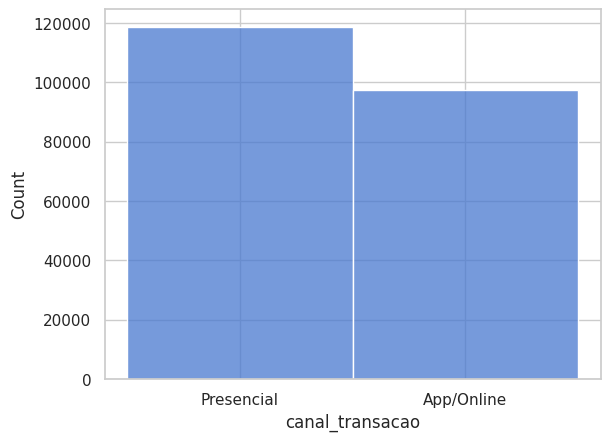

In [60]:
sns.histplot(data=df_transacoes, x="canal_transacao",bins =150)



# Exemplo 2 — distribuição pela categoria de compra

<Axes: xlabel='categoria', ylabel='Count'>

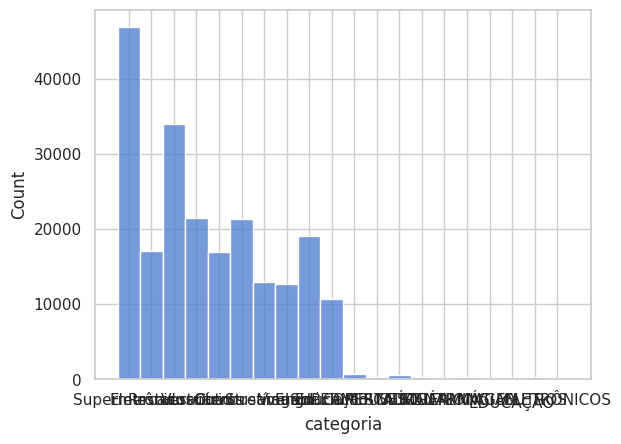

In [63]:
sns.histplot(data=df_transacoes, x="categoria",bins =3)

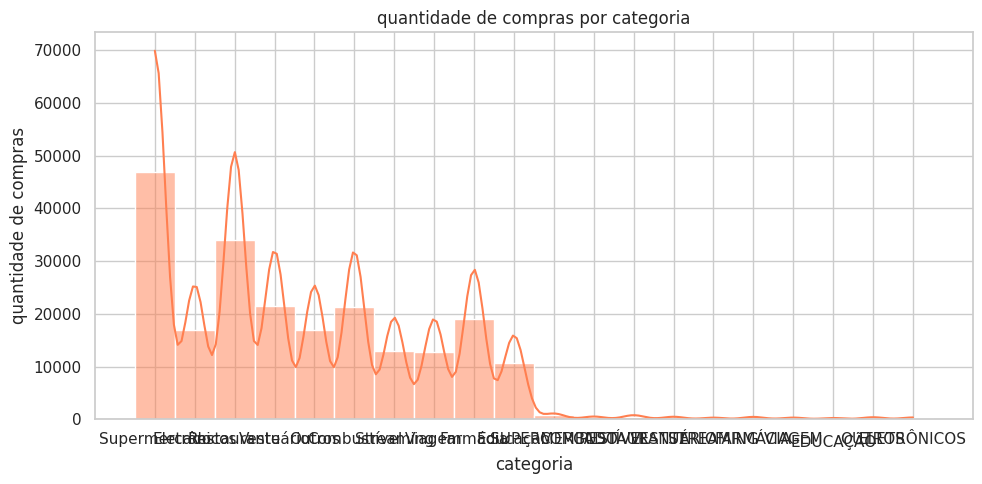

In [69]:
fig, ax = plt.subplots(figsize=(10,5)) # cria subáreas para poder trabalhar com gráficos independentes

sns.histplot(
    data=df_transacoes, # os dados/dataframe
    x="categoria", # coluna que vai ser usada no eixo X
    bins=40, # quantidade de agrupamentos
    kde=True, # linha com o a densidade de probabilidade linha laranja
    color="coral", # cor do gráfico
    ax=ax # subarea usada
)

ax.set_title("quantidade de compras por categoria") # define o título do gráfico
ax.set_xlabel("categoria") # define a legenda do eixo x
ax.set_ylabel("quantidade de compras") # define a legenda do eixo y

'''ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R$ {x/1000:.0f}k")
) # formata o valor exibido no eixo x
'''
plt.tight_layout() # ajuste de visual
plt.show() # plota os gráficos

#### Parâmetros importantes do `histplot`

| Parâmetro   | Função                                              | Exemplo                       |
|-------------|-----------------------------------------------------|-------------------------------|
| `bins`      | Número de barras                                    | `bins=30`                     |
| `kde`       | Curva de densidade sobreposta                       | `kde=True`                    |
| `hue`       | Separa grupos por cor                               | `hue="canal_transacao"`       |
| `alpha`     | Transparência (0 = invisível, 1 = opaco)            | `alpha=0.5`                   |
| `stat`      | O que medir: `"count"`, `"frequency"`, `"density"` | `stat="density"`              |
| `multiple`  | Como empilhar grupos: `"layer"`, `"stack"`, `"dodge"` | `multiple="dodge"`          |